# Amazon Clothing, Shoes, and Jewelry Q&A: Question Clustering & Answer Ambiguity

## Motivation
Amazon product Q&A contains thousands of customer questions and responses, but the information is not structured in a way that guarantees fast discovery of the most relevant or helpful answers. Questions vary widely in wording, and many products accumulate repeated themes (e.g., sizing, compatibility, material quality). Additionally, yes/no questions may produce ambiguous responses, which can reduce clarity for future shoppers.

This project applies data mining and NLP techniques to investigate whether semantic grouping and ambiguity detection can improve how Q&A information is organized and retrieved.

## Project Goal
Explore the Amazon Clothing, Shoes, and Jewelry Q&A dataset to:
- identify patterns in question text and product popularity,
- cluster similar questions to support better organization/retrieval,
- analyze what drives ambiguity in yes/no questions,
- evaluate whether transformer-based embeddings improve clustering compared to traditional methods.

## Research Questions
1. **Clustering + advanced language models:**  
   How can clustering and advanced language models be used to automatically group similar customer questions and improve retrieval of clear, helpful answers in Amazon’s Clothing, Shoes, and Jewelry Q&A data?

2. **Patterns among popular products:**  
   What patterns or clusters emerge among the most frequently asked questions for popular products?

3. **Ambiguity in yes/no questions:**  
   Which factors are most indicative of ambiguous answers to yes/no questions?

4. **Transformers vs traditional clustering:**  
   Can transformer-based language models improve the grouping and retrieval of semantically similar questions, compared to traditional clustering approaches?

## Roadmap (Notebook Structure)
This notebook will:
1. Load and validate the dataset.
2. Preprocess and perform exploratory data analysis (EDA), focusing on question/answer types and product frequency.
3. Build a TF-IDF + KMeans clustering baseline for questions associated with popular products.
4. Train a supervised baseline model (logistic regression) to predict ambiguous yes/no answers.
5. Compute transformer-based sentence embeddings (Sentence-BERT) and cluster using embedding similarity for comparison.
6. Summarize findings, address each research question, and discuss limitations and future directions.

## Data Loading & Dataset Overview

### Dataset
This project uses the **Amazon Clothing, Shoes, and Jewelry Q&A** dataset, which contains question/answer pairs along with metadata.

Each record includes (at minimum) the following fields:
- `question`: the customer question text
- `answer`: the customer answer text
- `questionType`: question category (e.g., `yes/no`, `open-ended`)
- `answerType`: yes/no label indicator for `yes/no` questions (e.g., `Y`, `N`, `?`)
- `asin`: product identifier
- `unixTime`, `answerTime`: timestamps used for basic temporal analysis

### Download + Loading Approach
The dataset is stored as a compressed JSONL file (`.json.gz`). During loading, each line is parsed into a Python object and converted into a Pandas DataFrame for analysis.

### Preprocessing (applied later in the notebook)
To standardize text inputs for modeling/clustering, the project applies:
- lowercasing
- punctuation/stopword handling
- filtering out missing or empty question/answer entries

This notebook begins by validating the dataset structure and inspecting basic shapes and sample rows before moving to preprocessing and EDA.

In [1]:
import os, ast, gzip
import pandas as pd

DATA_URL = "https://mcauleylab.ucsd.edu/public_datasets/data/amazon/qa/qa_Clothing_Shoes_and_Jewelry.json.gz"
FILE_PATH = "/content/data/qa_Clothing_Shoes_and_Jewelry.json.gz"

os.makedirs("data", exist_ok=True)

def download_dataset(url: str, to_path: str):
    import urllib.request
    print(f"Downloading from {url} ...")
    urllib.request.urlretrieve(url, to_path)
    size = os.path.getsize(to_path) / (1024*1024)
    print(f"Saved to {to_path} ({size:.2f} MB)")

# Uncomment to download when ready
download_dataset(DATA_URL, FILE_PATH)

# Path to the dataset in Colab (update if needed)
FILE_PATH = "/content/data/qa_Clothing_Shoes_and_Jewelry.json.gz"

# Load gzipped JSONL into a list of dicts
data = []
with gzip.open(FILE_PATH, "rt", encoding="utf-8") as f:
    for line_idx, line in enumerate(f):
        try:
            item = ast.literal_eval(line)
            data.append(item)
        except Exception as e:
            print("Error on line", line_idx, ":", e)

# Convert to DataFrame
df = pd.DataFrame(data)

print("Dataset shape:", df.shape)
display(df.head())

# Quick check for expected columns
print("\nColumns:", df.columns.tolist())

# Check missing values in key fields
print("\nMissing values (key fields):")
print(df[["question", "answer", "questionType", "answerType", "asin"]].isna().sum())

Saved to /content/data/qa_Clothing_Shoes_and_Jewelry.json.gz (0.95 MB)
Dataset shape: (22068, 7)


,questionType,asin,answerTime,unixTime,question,answerType,answer
0,yes/no,1608299627,"Jul 20, 2013",1.374304e+09,You bought level one . Will you buy the next l...,Y,Midway through I tried out Pimsleur and I foun...
1,yes/no,1608299627,"Jul 22, 2013",1.374476e+09,Will you buy the next level edition,?,My grandson likes the program and finds it eas...
2,yes/no,1608299627,"Jul 21, 2013",1.374390e+09,Did you learn Chinese,?,Not through Rosetta Stone. For 5 months I work...
3,yes/no,1617160040,"Nov 23, 2014",1.416730e+09,Do you see words written as well as hearing th...,Y,Yes
4,yes/no,1617160040,"Jan 15, 2013",1.358237e+09,does it work with windows 8?,?,I don't know but I'm getting ready to re-insta...



Columns: ['questionType', 'asin', 'answerTime', 'unixTime', 'question', 'answerType', 'answer']

Missing values (key fields):
question            0
answer              0
questionType        0
answerType      13878
asin                0
dtype: int64


### Initial Validation
The dataset loaded successfully with **22,068 rows** and **7 columns**.

Key observations:
- `questionType` and `question` are present for all rows.
- `answerType` is missing for many rows, which is expected because `answerType` mainly applies to `yes/no` questions.
- This will be important for later steps where ambiguous yes/no answers (`?`) are modeled.

The next step will focus on preprocessing and text cleaning to prepare questions for clustering and embedding-based semantic grouping.

In [2]:
# How answerType availability differs by questionType
qa_ans = df.groupby("questionType")["answerType"].apply(lambda s: s.isna().mean()).reset_index()
qa_ans.columns = ["questionType", "answerType_missing_fraction"]

print("Fraction of missing answerType by questionType (lower is better):")
display(qa_ans)

# Show counts for yes/no vs open-ended
print("\nQuestion type counts:")
display(df["questionType"].value_counts())

Fraction of missing answerType by questionType (lower is better):


,questionType,answerType_missing_fraction
0,open-ended,1.0
1,yes/no,0.0



Question type counts:


,count
questionType,
open-ended,13878
yes/no,8190


### Answer Type Availability
The `answerType` field is only meaningful for `yes/no` questions:

- For **`yes/no`** questions, `answerType` has **0% missing values**.
- For **`open-ended`** questions, `answerType` is **100% missing**, indicating that `answerType` does not apply to these records.

This shapes later modeling choices:
- For ambiguity detection, the project will train models using **only `yes/no` questions** where `answerType` is available.
- For clustering, the project will cluster based on question text, optionally focusing on specific subsets such as questions from **popular products** (top ASINs).

## Text Preprocessing

To support clustering (TF-IDF / KMeans) and semantic grouping (Sentence-BERT embeddings), question text must be standardized.

This project applies the following preprocessing to the question field:
1. **Lowercasing** to reduce case-related variation.
2. **Removing punctuation / non-word characters** (token cleanup).
3. **Optional stopword removal** (used depending on the vectorizer/embedding step).
4. **Filtering** rows with missing or empty question text (and later, filtering answerType where needed).

This notebook will create a cleaned question column that is used for downstream modeling.

In [3]:
import re
import pandas as pd

# Copy original data
df_proc = df.copy()

def clean_text(text: str) -> str:
    if pd.isna(text):
        return ""
    text = str(text).lower()
    # Replace non-alphanumeric characters with spaces, then collapse whitespace
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Clean questions
df_proc["question_clean"] = df_proc["question"].apply(clean_text)

# Filter out empty questions after cleaning
before = len(df_proc)
df_proc = df_proc[df_proc["question_clean"].str.len() > 0].copy()
after = len(df_proc)

print(f"Rows before filtering empty questions: {before}")
print(f"Rows after filtering empty questions: {after}")
print("\nSample cleaned text:")
display(df_proc[["question", "question_clean"]].head(10))

# For ambiguity modeling: use only yes/no where answerType exists
df_yesno = df_proc[df_proc["questionType"] == "yes/no"].copy()

print("Usable rows for clustering (all question types with cleaned questions):", len(df_proc))
print("Usable rows for ambiguity modeling (yes/no only):", len(df_yesno))
print("\nAmbiguity label distribution (yes/no):")
display(df_yesno["answerType"].value_counts(dropna=False))

Rows before filtering empty questions: 22068
Rows after filtering empty questions: 22068

Sample cleaned text:


,question,question_clean
0,You bought level one . Will you buy the next l...,you bought level one will you buy the next levels
1,Will you buy the next level edition,will you buy the next level edition
2,Did you learn Chinese,did you learn chinese
3,Do you see words written as well as hearing th...,do you see words written as well as hearing th...
4,does it work with windows 8?,does it work with windows 8
5,can two people take at the same time,can two people take at the same time
6,does it work on windows vista?,does it work on windows vista
7,How many people can use the software?,how many people can use the software
8,i'm traveling to italy to visit relatives who ...,i m traveling to italy to visit relatives who ...
9,Can more than one person use this software? Or...,can more than one person use this software or ...


Usable rows for clustering (all question types with cleaned questions): 22068
Usable rows for ambiguity modeling (yes/no only): 8190

Ambiguity label distribution (yes/no):


,count
answerType,
?,4356
Y,2521
N,1313


### Preprocessing Summary
After cleaning, the dataset still contains **22,068 rows**. No rows were removed because all `question` entries already contained usable text after lowercasing and punctuation cleanup.

The cleaned question text (`question_clean`) is standardized for modeling by:
- converting to lowercase,
- removing punctuation/non-word characters,
- collapsing repeated whitespace.

Example transformations include:
- `"You bought level one . Will you buy the next l..."` →
  `"you bought level one will you buy the next levels"`
- `"does it work with windows 8?"` →
  `"does it work with windows 8"`

### Task-specific filtering (yes/no ambiguity)
For ambiguity analysis, only `yes/no` questions contain `answerType`. This reduces the usable dataset from:
- **22,068** total records (for clustering/text analysis)
to **8,190** records (for supervised ambiguity prediction).

Within the `yes/no` subset, the `answerType` distribution is:
- **? (ambiguous): 4,356**
- **Y: 2,521**
- **N: 1,313**

In [4]:
# Quick check: how much the cleaning changed typical questions?
df_proc["changed_text"] = df_proc["question_clean"] != df_proc["question"].astype(str).str.lower()

print("Fraction of questions whose text changed after cleaning:")
display(df_proc["changed_text"].mean())

Fraction of questions whose text changed after cleaning:


np.float64(0.8999456226209896)

### Cleaning Impact
Although no rows were removed, preprocessing still substantially modified the text: about **90%** of questions changed after cleaning. This confirms that punctuation/format normalization (and whitespace cleanup) helps standardize the input for both TF-IDF-based clustering and transformer embeddings.

## Exploratory Data Analysis (EDA)

EDA helps identify dataset structure and motivates the modeling choices used later in the notebook.

This section focuses on:
1. **Question type distribution** (`open-ended` vs `yes/no`)
2. **Answer type distribution** for `yes/no` questions (including ambiguous `?`)
3. **Which products generate the most questions** (top ASINs)
4. Basic **temporal coverage** of when answers were provided
5. Common **lexical patterns** in question wording (most frequent tokens)

These insights guide:
- subset selection for clustering experiments (e.g., popular products),
- the supervised setup for predicting ambiguity in yes/no questions,
- interpretation of clustering outputs.

Question type distribution:


,count
questionType,
open-ended,13878
yes/no,8190


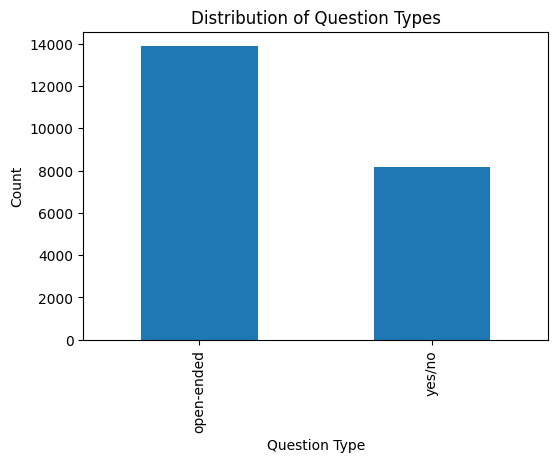

In [5]:
import matplotlib.pyplot as plt

# Distribution of question types
print("Question type distribution:")
display(df_proc["questionType"].value_counts())

ax = df_proc["questionType"].value_counts().plot(kind="bar", figsize=(6,4))
ax.set_title("Distribution of Question Types")
ax.set_xlabel("Question Type")
ax.set_ylabel("Count")
plt.show()

Answer type distribution (yes/no only):


,count
answerType,
?,4356
Y,2521
N,1313


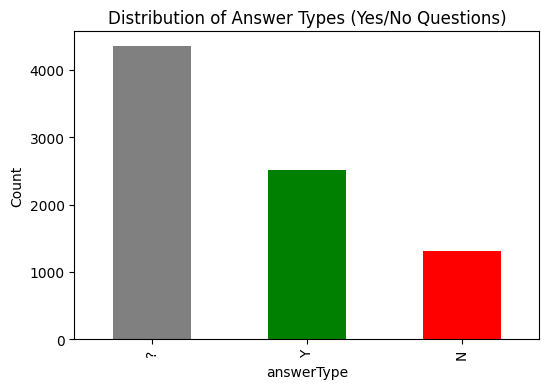

In [6]:
# Yes/no only: answerType distribution
df_yesno = df_proc[df_proc["questionType"] == "yes/no"].copy()

print("Answer type distribution (yes/no only):")
display(df_yesno["answerType"].value_counts(dropna=False))

ax = df_yesno["answerType"].value_counts().plot(
    kind="bar", figsize=(6,4), color=["gray","green","red"]
)
ax.set_title("Distribution of Answer Types (Yes/No Questions)")
ax.set_xlabel("answerType")
ax.set_ylabel("Count")
plt.show()

Top 10 most-asked-about ASINs:


,count
asin,
B00JL9AY02,36
B00BKEQBI0,30
B00JL9AXXA,20
B005345DBY,18
B00529PYU0,14
B0093R349U,12
B00849FLW6,10
B008402S3K,10
B008402RQI,10


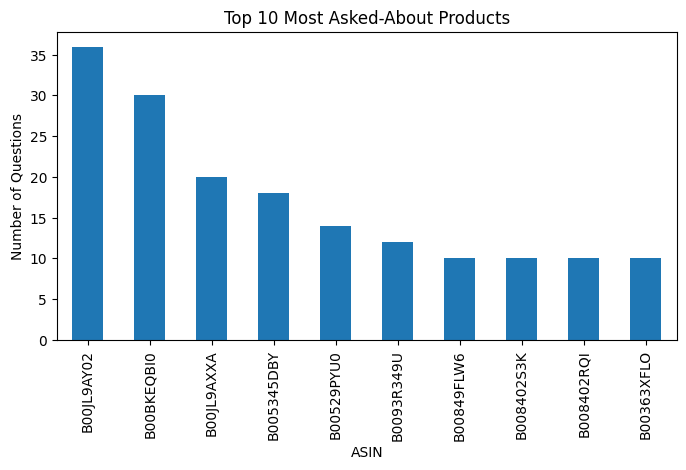

In [7]:
# Top ASINs by question count
top_asins = df_proc["asin"].value_counts().head(10)
print("Top 10 most-asked-about ASINs:")
display(top_asins)

ax = top_asins.plot(kind="bar", figsize=(8,4))
ax.set_title("Top 10 Most Asked-About Products")
ax.set_xlabel("ASIN")
ax.set_ylabel("Number of Questions")
plt.show()

Earliest and latest answer dates:
2007-04-28 07:00:00 - 2015-05-01 07:00:00


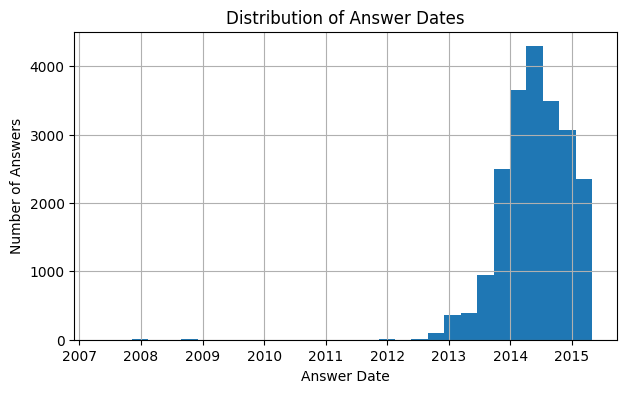

In [8]:
# Convert unixTime to datetime and show range
df_proc["answer_dt"] = pd.to_datetime(df_proc["unixTime"], unit="s", errors="coerce")

print("Earliest and latest answer dates:")
print(df_proc["answer_dt"].min(), "-", df_proc["answer_dt"].max())

plt.figure(figsize=(7,4))
df_proc["answer_dt"].dropna().hist(bins=30)
plt.title("Distribution of Answer Dates")
plt.xlabel("Answer Date")
plt.ylabel("Number of Answers")
plt.show()

Most common question tokens:
the: 13592
i: 10228
a: 8997
is: 8734
size: 7408
what: 5524
to: 4947
it: 4938
this: 4868
for: 4694
and: 4581
in: 3834
or: 3779
are: 3418
these: 3129


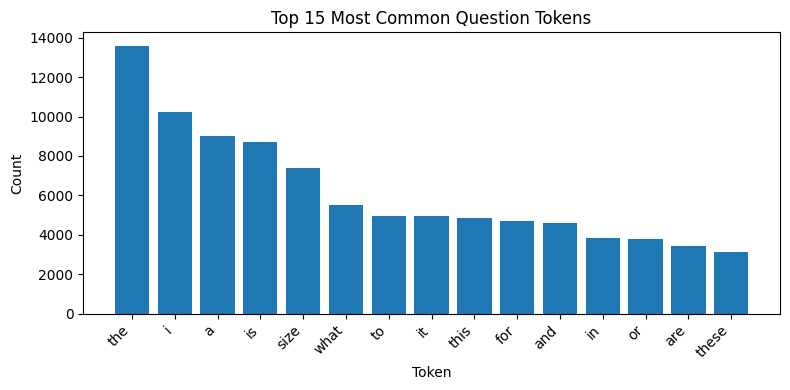

In [9]:
from collections import Counter
import re

# Tokenize cleaned questions for frequency analysis
tokens = []
for q in df_proc["question_clean"].dropna().tolist():
    # split on whitespace (already cleaned)
    tokens.extend(q.split())

word_counts = Counter(tokens)
most_common_words = word_counts.most_common(15)

print("Most common question tokens:")
for word, count in most_common_words:
    print(f"{word}: {count}")

# Optional bar plot
words, counts = zip(*most_common_words)
plt.figure(figsize=(8,4))
plt.bar(words, counts)
plt.title("Top 15 Most Common Question Tokens")
plt.xlabel("Token")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### EDA Takeaways
- **Question types:** More **open-ended** than **yes/no** questions (`open-ended: 13,878`, `yes/no: 8,190`), so ambiguity modeling applies only to the yes/no subset.
- **Ambiguity signal in yes/no:** Ambiguous answers (`?`) are common (`? = 4,356`, `Y = 2,521`, `N = 1,313`), motivating a supervised ambiguity baseline.
- **Product concentration:** Questions are focused around relatively popular products (top ASIN has **36** questions), motivating clustering on **top ASINs**.
- **Temporal coverage:** Answers range from **2007-04-28** to **2015-05-01**; time helps context but the main tasks are text-based.
- **Lexical patterns:** Frequently occurring tokens (e.g., “the”, “i”, “size”, “what”) show that word frequency alone is insufficient for semantic grouping—supporting TF‑IDF and transformer embeddings.


## Problem Formulation (What to Cluster / What to Predict)

This project has two tasks using the same dataset:

### Task A — Question clustering (unsupervised)
- **Cluster:** question text
- **Methods:** TF‑IDF + KMeans (baseline) and Sentence‑BERT embeddings + KMeans (semantic)
- **Interpretation:** clusters should correspond to recurring themes (fit, size, compatibility, usage, quality)
- **Subset strategy:** cluster questions from **top ASINs** to ensure enough data per product

### Task B — Ambiguity prediction (supervised, yes/no only)
- **Predict:** whether a yes/no answer is **ambiguous**
- **Labels:** `?` → 1 (ambiguous), `Y/N` → 0 (not ambiguous)
- **Filtering:** `answerType` exists only for `questionType = yes/no`
- **Baseline features:** question length and ASIN frequency
- **Evaluation:** classification metrics (precision/recall/F1)

Together, Task A tests whether semantic structure exists in question phrasing (and whether embeddings improve clustering), while Task B tests whether ambiguity correlates with observable question/product signals.

## Clustering baseline using TF‑IDF + KMeans

To establish a baseline for “group similar questions,” a traditional unsupervised pipeline is used:

1. **Select a clustering subset:** questions associated with the **most frequently asked products (top ASINs)**.
   - Rationale: popular products provide enough repeated questions to form meaningful clusters and comparisons.

2. **Represent questions with TF‑IDF:**
   - TF‑IDF converts each question into a sparse vector of weighted token importance.
   - English stopwords are removed to reduce noise from common words.

3. **Cluster with KMeans:**
   - KMeans partitions TF‑IDF vectors into `k` clusters based on feature similarity.
   - Cluster sizes provide an initial diagnostic for whether the data forms distinct groupings.

This baseline is used both as a feasibility check and as a comparison point for later transformer-based embedding clustering.

Subset size (questions from top 10 ASINs): 170
TF-IDF matrix shape: (170, 367)
Cluster sizes: Counter({np.int32(0): 110, np.int32(1): 34, np.int32(3): 13, np.int32(4): 7, np.int32(2): 6})


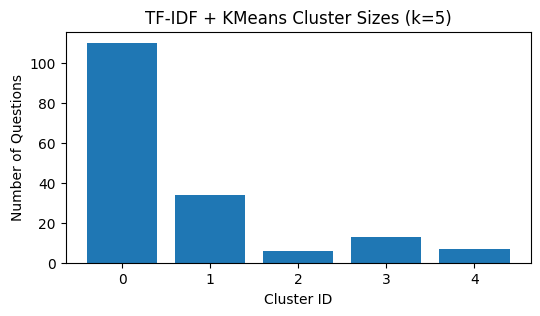

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from collections import Counter
import numpy as np

# --- 1) Choose popular products (top ASINs) ---
top_n = 10
top_asins_list = df_proc["asin"].value_counts().head(top_n).index.tolist()

# Select questions from those ASINs
subset = df_proc[df_proc["asin"].isin(top_asins_list)].copy()
popular_questions = subset["question_clean"].fillna("").tolist()

print(f"Subset size (questions from top {top_n} ASINs):", len(popular_questions))

# --- 2) TF-IDF representation ---
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=2000,   # reduce dimensionality for faster clustering
    lowercase=False       # already lowercased in question_clean
)
X = vectorizer.fit_transform(popular_questions)

print("TF-IDF matrix shape:", X.shape)

# --- 3) KMeans clustering ---
k = 5  # feasibility test; later this can be tuned
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
labels = kmeans.fit_predict(X)

# --- 4) Cluster size diagnostic ---
cluster_sizes = Counter(labels)
print("Cluster sizes:", cluster_sizes)

# Optional: visualize cluster sizes
import matplotlib.pyplot as plt

plt.figure(figsize=(6,3))
plt.bar(list(cluster_sizes.keys()), list(cluster_sizes.values()))
plt.title(f"TF-IDF + KMeans Cluster Sizes (k={k})")
plt.xlabel("Cluster ID")
plt.ylabel("Number of Questions")
plt.show()

### TF-IDF + KMeans Baseline Results

Using TF-IDF vectors (`max_features=2000`) and KMeans with **k = 5** on questions from the **top 10 ASINs**, the clustering subset contained **170 questions**.

The resulting cluster sizes were highly imbalanced:
- Cluster 0: **110**
- Cluster 1: **34**
- Cluster 3: **13**
- Cluster 4: **7**
- Cluster 2: **6**

This distribution suggests that within popular products, some question themes repeat strongly (forming large clusters), while many other themes appear less frequently and end up as small clusters. The feasibility takeaway is that clustering can discover structure, but TF-IDF/KMeans may produce uneven groupings because it relies on lexical overlap and cannot fully capture semantic similarity.

These limitations motivate comparing against transformer-based embeddings (Sentence-BERT), which aim to represent meaning more directly.

## Ambiguity modeling: Logistic Regression baseline

To predict whether a `yes/no` answer will be **ambiguous**, a simple supervised baseline is trained.

**Problem setup**
- **Only `yes/no` questions** have `answerType` labels.
- **Target variable (y):**
  - `ambiguous = 1` if `answerType == '?'`
  - `ambiguous = 0` if `answerType` is `Y` or `N`

**Baseline features (simple, interpretable)**
This baseline uses lightweight features derived from:
- **question length** (character length), which may correlate with hedging/clarification behavior
- **ASIN frequency** (how often the product appears in the dataset), which captures product context and may proxy for question distribution differences

**Model**
- Logistic Regression classifier
- Train/test split with a fixed random seed for repeatability

**Evaluation**
- Classification report (precision, recall, F1) is used to assess whether ambiguity (`?`) can be detected reliably.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Use only yes/no questions (answerType is defined here)
yesno = df_proc[df_proc["questionType"] == "yes/no"].copy()

# Define target: ambiguous if '?'
yesno = yesno.dropna(subset=["answerType", "question_clean"])
y = (yesno["answerType"] == "?").astype(int)

# Simple feature set
question_len = yesno["question_clean"].apply(len)

# Product frequency feature (based on full dataset counts)
asin_freq_map = df_proc["asin"].value_counts()
asin_freq = yesno["asin"].map(asin_freq_map)

X_feat = pd.DataFrame({
    "question_length": question_len,
    "asin_freq": asin_freq
})

print("Feature preview:")
display(X_feat.head())
print("\nTarget distribution (1=ambiguous '?'):")
print(y.value_counts())

# Split + train
X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y, test_size=0.2, random_state=42, stratify=y
)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("\nLogistic Regression classification report:")
print(classification_report(y_test, y_pred, target_names=["not ambiguous (Y/N)", "ambiguous (?)"]))

Feature preview:


,question_length,asin_freq
0,49,3
1,35,3
2,21,3
3,146,5
4,27,5



Target distribution (1=ambiguous '?'):
answerType
1    4356
0    3834
Name: count, dtype: int64

Logistic Regression classification report:
                     precision    recall  f1-score   support

not ambiguous (Y/N)       0.54      0.47      0.50       767
      ambiguous (?)       0.58      0.64      0.61       871

           accuracy                           0.56      1638
          macro avg       0.56      0.56      0.56      1638
       weighted avg       0.56      0.56      0.56      1638



### Interpretation: Logistic Regression baseline

The ambiguity classification baseline predicts whether a `yes/no` answer is ambiguous (`answerType == '?'`), using two simple features: **question length** and **ASIN frequency**.

The target distribution is nearly balanced but with slightly more ambiguous labels:
- `ambiguous (?) = 4,356`
- `not ambiguous (Y/N) = 3,834`

Model performance on the test set achieved an **accuracy of ~0.56**. For the ambiguous class (`?`):
- **precision = 0.58**
- **recall = 0.64**
- **F1 = 0.61**

For the non-ambiguous class (Y/N):
- **precision = 0.54**
- **recall = 0.47**
- **F1 = 0.50**

Ambiguity in `yes/no` questions appears to be **partly predictable from simple, non-semantic signals**. The logistic regression baseline (question length + ASIN frequency) achieves strong **recall for ambiguous answers (`?`): ≈ 0.64**, indicating that `?` cases correlate with observable patterns such as question form/complexity and product context. However, the model’s moderate overall accuracy shows that these features alone do not fully capture ambiguity, which likely also depends on deeper semantic cues and uncertainty in how responses are framed.

## Transformer embeddings + clustering

A limitation of the TF‑IDF + KMeans baseline is that it primarily captures **lexical overlap**, not deeper meaning. To cluster questions by semantics, this section uses transformer-based sentence embeddings.

**Approach**
1. **Embed questions** using Sentence-BERT (`sentence-transformers`).
   - Each question is mapped into a dense vector that represents its semantic meaning.

2. **Cluster embeddings with KMeans**
   - KMeans groups embedded questions by similarity in embedding space.

**Clustering subset**
- The same subset strategy as before can be used (e.g., questions from top ASINs) to keep comparisons fair and to focus on products with enough question volume.

**Why embeddings?**
Sentence-BERT embeddings aim to place semantically similar questions closer together, so clusters are expected to align more closely with underlying themes (e.g., sizing, compatibility, material/quality) than TF‑IDF lexical clusters.

In [12]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from collections import Counter
import numpy as np

# Subset: questions from top ASINs (same as clustering baseline)
top_n = 10
top_asins_list = df_proc["asin"].value_counts().head(top_n).index.tolist()
subset = df_proc[df_proc["asin"].isin(top_asins_list)].copy()

questions = subset["question_clean"].fillna("").tolist()
print(f"Subset size (top {top_n} ASINs):", len(questions))

# Load Sentence-BERT model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Create embeddings (can be slow; for reproducibility keep batch_size reasonable)
embeddings = model.encode(questions, show_progress_bar=True)

print("Embedding matrix shape:", embeddings.shape)

# Cluster embeddings
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
labels = kmeans.fit_predict(embeddings)

print("SBERT cluster sizes:", Counter(labels))

Subset size (top 10 ASINs): 170


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Embedding matrix shape: (170, 384)
SBERT cluster sizes: Counter({np.int32(0): 42, np.int32(3): 39, np.int32(2): 36, np.int32(1): 31, np.int32(4): 22})


### Interpretation: Transformer embeddings + KMeans

For clustering based on semantics, Sentence-BERT (`all-MiniLM-L6-v2`) was used to embed each question into a dense vector (embedding dimension: **384**). KMeans was then applied to group embeddings into **k = 5** clusters using Euclidean similarity in embedding space.

For the same subset size as the TF‑IDF baseline (**170 questions from the top 10 ASINs**), the resulting SBERT cluster sizes were:
- Cluster 0: **42**
- Cluster 1: **31**
- Cluster 2: **36**
- Cluster 3: **39**
- Cluster 4: **22**

Compared to the TF‑IDF + KMeans baseline (which produced a highly imbalanced distribution such as **110** vs **6**), the embedding-based clustering produces a **more balanced cluster size distribution**. This suggests that transformer embeddings capture semantic similarity in a way that spreads questions across themes more evenly, instead of clustering being dominated by surface-level lexical overlap.

In [13]:
import pandas as pd

# Recreate subset index for mapping questions back to cluster ids
subset = df_proc[df_proc["asin"].isin(top_asins_list)].copy()
subset = subset.reset_index(drop=True)

subset["sbert_cluster"] = labels

# Display a few representative questions per cluster
samples_per_cluster = 5
for c in sorted(subset["sbert_cluster"].unique()):
    print(f"\n=== SBERT cluster {c} (showing {samples_per_cluster} questions) ===")
    display(subset[subset["sbert_cluster"] == c][["question_clean", "questionType", "asin"]].head(samples_per_cluster))


=== SBERT cluster 0 (showing 5 questions) ===


,question_clean,questionType,asin
28,can i wash it,yes/no,B005345DBY
37,can i wash it,yes/no,B005345DBY
43,what is the warranty on this product,open-ended,B008402RQI
44,is it easy to mount on the wall do we need to ...,open-ended,B008402RQI
46,how is this holding up for everyone some say i...,open-ended,B008402RQI



=== SBERT cluster 1 (showing 5 questions) ===


,question_clean,questionType,asin
11,i want to buy this band as a gift and i want t...,open-ended,B00529PYU0
12,i want to purchase this and repurpose the band...,yes/no,B00529PYU0
13,i have a green ipod nano touch if i get this b...,open-ended,B00529PYU0
14,is it only compatible with ipod or would it wo...,open-ended,B00529PYU0
18,i want to buy this band as a gift and i want t...,open-ended,B00529PYU0



=== SBERT cluster 2 (showing 5 questions) ===


,question_clean,questionType,asin
5,yes please tell me how heavy and is the materi...,open-ended,B00363XFLO
7,the lining of this rain suit is it a mesh lini...,open-ended,B00363XFLO
8,would this be a good choice to use for golfing,yes/no,B00363XFLO
9,pvc type rain suits seem to crack and fall apa...,open-ended,B00363XFLO
15,is the finish on the black one a glossy metall...,open-ended,B00529PYU0



=== SBERT cluster 3 (showing 5 questions) ===


,question_clean,questionType,asin
16,could i use this band for a normal watch that ...,yes/no,B00529PYU0
23,could i use this band for a normal watch that ...,yes/no,B00529PYU0
86,what s the range on the watch does the phone h...,open-ended,B00BKEQBI0
87,is it difficult to see the screen outside,yes/no,B00BKEQBI0
92,what is the difference between the 99 dollar w...,open-ended,B00BKEQBI0



=== SBERT cluster 4 (showing 5 questions) ===


,question_clean,questionType,asin
0,what are the sizing dimensions,open-ended,B00363XFLO
1,saw coleman s sizing chart on site but want to...,open-ended,B00363XFLO
2,i m 5 7 i going to use over my clothes which s...,open-ended,B00363XFLO
3,i wear a 38 x 32 w l what size do you think i ...,open-ended,B00363XFLO
4,i am 155lb 5 7 30 inseam pants fit me well sho...,open-ended,B00363XFLO


### Qualitative cluster examples (SBERT)
A small qualitative review of SBERT clusters shows that semantic clustering groups questions around recognizable product-related themes:

- **Cluster 0:** mixes installation/usage context and general product concerns (e.g., “can I wash it”, “warranty” and mounting/holding up questions).
- **Cluster 1:** appears to focus on purchasing intent and compatibility/fit for related devices (e.g., gifting, repurposing, compatibility with iPod).
- **Cluster 2:** mixes clothing-material details and functional suitability questions (rain suit lining/mesh, material properties) along with a yes/no suitability question (“good choice to use for golfing”).
- **Cluster 3:** centers on device/watch compatibility and practical usability constraints (e.g., “use this band for a normal watch”, screen visibility outdoors).
- **Cluster 4:** shows strong “sizing”/fit-related intent, with multiple questions about sizing dimensions and how measurements translate to real sizing charts.

These examples support the hypothesis that transformer embeddings capture meaning better than TF‑IDF lexical overlap, yielding clusters that align with intuitive customer intent (warranty, compatibility, usability, sizing).

## “So what?” Conclusions

### Research question answers
1. **Clustering + advanced language models**  
   Question text can be clustered using text representations. TF‑IDF + KMeans yields meaningful groups, and Sentence‑BERT embeddings + KMeans produce clusters that align more closely with recognizable intent themes. While clustering does not measure answer helpfulness directly, it shows the dataset has exploitable semantic structure for organizing questions.

2. **Patterns in questions for popular products**  
   Focusing on **top ASINs** makes it possible to inspect repeated question themes across products. SBERT clusters reveal recurring patterns such as **warranty/installation**, **compatibility and usage**, **material/lining details**, **practical usability**, and **sizing/fit**—indicating that many popular products generate repetitive, learnable intents.

3. **Factors behind ambiguous yes/no answers**  
   A logistic regression baseline using **question length** and **ASIN frequency** predicts ambiguity (`?`) with **0.56 accuracy** and **recall ≈ 0.64** for the ambiguous class. This suggests ambiguity is correlated with observable signals (question form/context), though performance remains moderate, indicating semantic cues likely also matter.

4. **Transformers vs traditional clustering**  
   Transformer embeddings improve the clustering outcome for the same setup: TF‑IDF + KMeans produced highly imbalanced cluster sizes (e.g., **110 vs 6**), while SBERT + KMeans produced a more even distribution (**42, 31, 36, 39, 22**). Example clusters also appear more meaning-aligned than lexical-overlap clusters, supporting transformer-based semantic representations for grouping.

### Limitations
- **Simple ambiguity features:** logistic regression relies on a small, non-semantic feature set (length + ASIN frequency).
- **KMeans hyperparameter sensitivity:** results depend on the chosen number of clusters `k`.
- **No direct helpfulness evaluation:** clustering groups similar questions, but does not automatically select the most helpful answers without a downstream retrieval/ranking step.

### Future work
- Add a **retrieval/ranking step** using cluster/embedding neighbors to recommend candidate answers and evaluate usefulness.
- Use **text-based representations** for ambiguity prediction (e.g., transformer embeddings) instead of only length/frequency.
- Assess clustering quality more rigorously (e.g., silhouette/topic coherence proxy or manual theme labeling) and compare across multiple `k` values.

In [14]:
!pip freeze > requirements.txt
from google.colab import files
files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>